In [2]:
import pyvisa
print(pyvisa.ResourceManager().list_resources())      

('USB0::0x1AB1::0x04B0::DS2D242101480::INSTR',)


In [8]:
pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 6.1 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.9 MB 7.3 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.9 MB 7.3 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/9.9 MB 7.2 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 7.2 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 7.2 MB/s  0:00:01

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
  

Verbonden met: RIGOL TECHNOLOGIES,DS2102A,DS2D242101480,00.03.06
Data ophalen...
Grafiek wordt getoond...


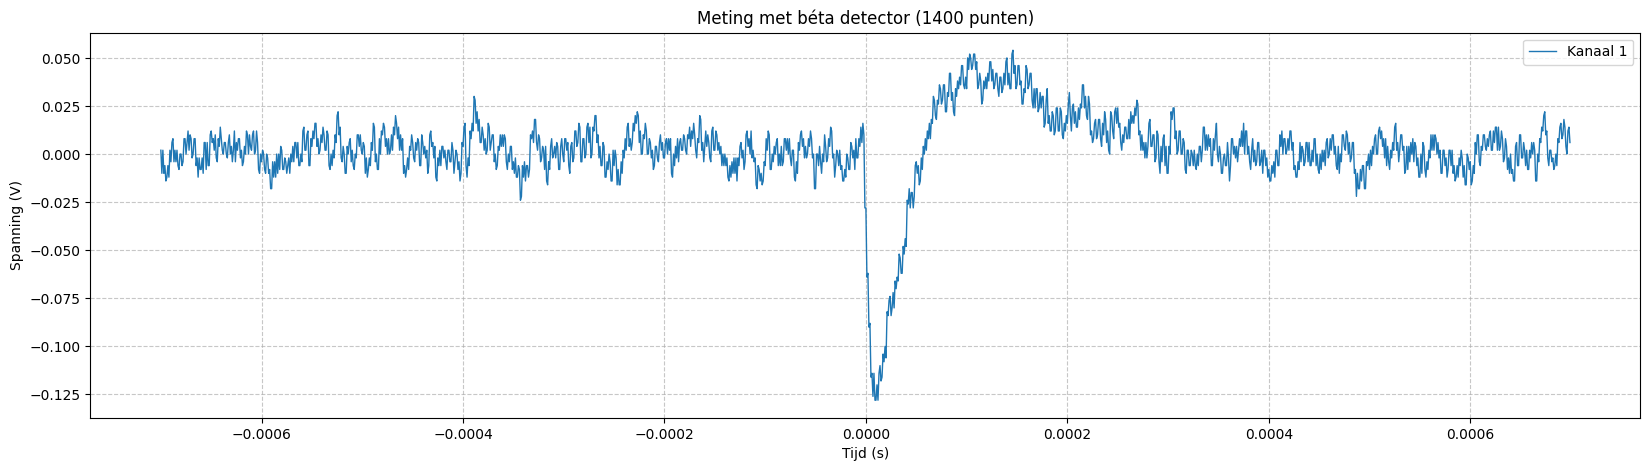

Verbinding gesloten.


In [4]:
import pyvisa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Verbinding maken met jouw apparaat
rm = pyvisa.ResourceManager()
instrument_address = 'USB0::0x1AB1::0x04B0::DS2D242101480::INSTR'

try:
    scope = rm.open_resource(instrument_address)
    scope.timeout = 20000 
    print(f"Verbonden met: {scope.query('*IDN?').strip()}")

    # 2. Instellingen voor data-overdracht
    scope.write(':WAVeform:SOURce CHANnel1')
    scope.write(':WAVeform:FORMat ASCII')
    scope.write(':WAVeform:MODE NORM') 

    
    
    # 3. Data ophalen
    print("Data ophalen...")
    raw_response = scope.query(':WAVeform:DATA?')
    
    # Header verwijderen (#9000001401...)
    if raw_response.startswith('#'):
        data_string = raw_response[11:]
    else:
        data_string = raw_response

    # Omzetten naar getallen
    signaal = np.fromstring(data_string, sep=',')

    # --- DE FIX: Laatste punt verwijderen (stopt de lijn omlaag) ---
    if len(signaal) > 0:
        signaal = signaal[:-1] 

    # 4. Tijd-as berekenen
    x_increment = float(scope.query(':WAVeform:XINCrement?'))
    x_origin = float(scope.query(':WAVeform:XORigin?'))
    
    # Tijd-as genereren op basis van de ingekorte lijst
    tijd = np.arange(0, len(signaal)) * x_increment + x_origin

    
    # 5. Plotten (Standaard witte achtergrond)
    plt.figure(figsize=(20, 5))
    
    # We gebruiken een blauwe lijn voor betere leesbaarheid op wit
    plt.plot(tijd, signaal, color='tab:blue', linewidth=1, label='Kanaal 1')
    
    plt.title(f"Meting met béta detector ({len(signaal)} punten)")
    plt.xlabel("Tijd (s)")
    plt.ylabel("Spanning (V)")
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    print("Grafiek wordt getoond...")
    plt.show()

except Exception as e:
    print(f"Er is een fout opgetreden: {e}")

finally:
    if 'scope' in locals():
        scope.close()
        print("Verbinding gesloten.")

pd.DataFrame({'Tijd (s)': tijd, 'Spanning (V)': signaal}).to_csv('meting_9.csv', index=False)




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#Meting eigen bron jozalt
Meting_onbekende_bron = (14 + 13 + 14)/3 #jozosalt 5 minuten
print("Gemiddelde meting onbekende bron:", Meting_onbekende_bron)

#Metingen verschillende concentraties KCl
Gemiddelde_Meting_20procent = (5 + 7 + 5)/3
Gemiddelde_Meting_40procent = (8 + 8 + 9)/3
Gemiddelde_Meting_60procent = (16 + 9 + 13)/3
Gemiddelde_Meting_80procent = ( 14 + 11 + 17)/3
Gemiddelde_Meting_100procent = (16 + 18 +13)/3

#Gemiddelde meting berekenen
print("Gemiddelde meting 20 procent KCl:", Gemiddelde_Meting_20procent)
print("Gemiddelde meting 40 procent KCl:", Gemiddelde_Meting_40procent)
print("Gemiddelde meting 60 procent KCl:", Gemiddelde_Meting_60procent)
print("Gemiddelde meting 80 procent KCl:", Gemiddelde_Meting_80procent)
print("Gemiddelde meting 100 procent KCl:", Gemiddelde_Meting_100procent)

#Tijdmeting met 100 procent KCl
Tijd = np.array([1, 3, 5, 7, 9])
Metingen = np.array([3, 9, 16, 21, 28])


Gemiddelde meting onbekende bron: 13.666666666666666
Gemiddelde meting 20 procent KCl: 5.666666666666667
Gemiddelde meting 40 procent KCl: 8.333333333333334
Gemiddelde meting 60 procent KCl: 12.666666666666666
Gemiddelde meting 80 procent KCl: 14.0
Gemiddelde meting 100 procent KCl: 15.666666666666666


<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
C:\Users\nadin\AppData\Local\Temp\ipykernel_22584\3811876273.py:24: SyntaxWarning: invalid escape sequence '\s'
  ecolor='darkgreen', capsize=2, label='Metingen met foutmarge ($\sqrt{N}$)')


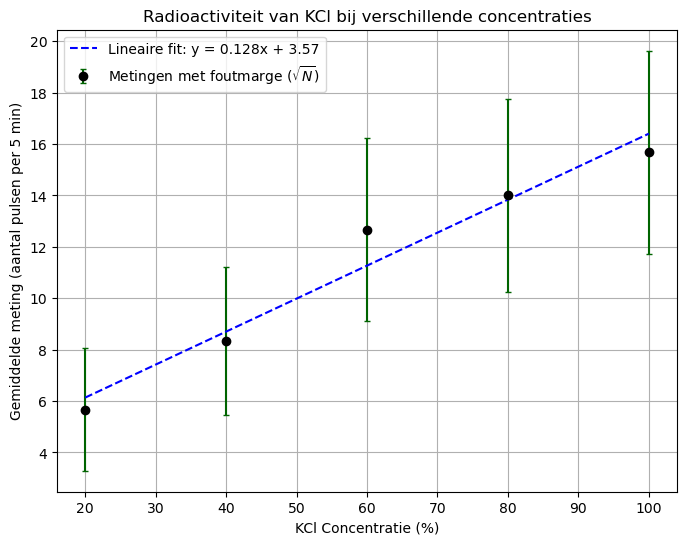

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
metingen = np.array([5.67, 8.33, 12.67, 14.00, 15.67])
Percentages = np.array([20, 40, 60, 80, 100])

# Foutamrge op metingen
foutmarge = np.array([np.sqrt(5.67), np.sqrt(8.33), np.sqrt(12.67), np.sqrt(14.00), np.sqrt(15.67)])

# Data fitten
def linear(x, a, b):
    return a * x + b

# Curve fit
popt, pcov = curve_fit(linear, Percentages, metingen)
a_fit, b_fit = popt

# Grafiek plotten
plt.figure(figsize=(8, 6))

plt.errorbar(Percentages, metingen, yerr=foutmarge, fmt='o', color='black', 
             ecolor='darkgreen', capsize=2, label='Metingen met foutmarge ($\sqrt{N}$)')

plt.plot(Percentages, linear(Percentages, a_fit, b_fit), 
         label=f'Lineaire fit: y = {a_fit:.3f}x + {b_fit:.2f}', linestyle='--', color='blue')

plt.title("Radioactiviteit van KCl bij verschillende concentraties")
plt.xlabel("KCl Concentratie (%)")
plt.ylabel("Gemiddelde meting (aantal pulsen per 5 min)")
plt.grid(True)
plt.legend()

plt.show()



In [6]:
# Massapercentage berekenen onbekende bron
Meting_onbekende_bron = (14 + 13 + 14)/3
print("Gemiddelde meting onbekende bron:", Meting_onbekende_bron)
percentace_onbekende_brond = (Meting_onbekende_bron - 3.57) / 0.128
print(f"Geschat massapercentage van de onbekende bron: {percentace_onbekende_brond:.2f}%")

Gemiddelde meting onbekende bron: 13.666666666666666
Geschat massapercentage van de onbekende bron: 78.88%


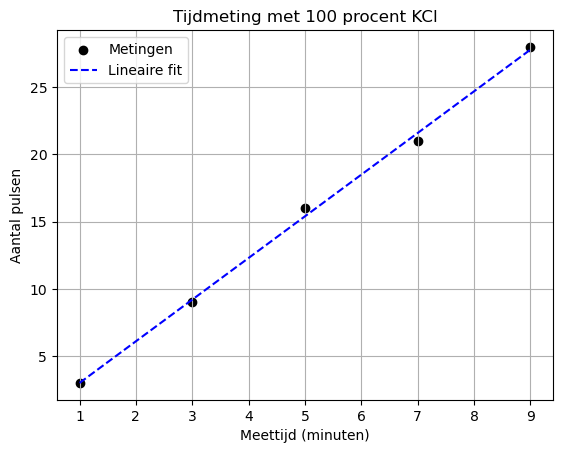

In [35]:
def linear(x, a, b):
    return a * x + b

# Curve fit
popt, pcov = curve_fit(linear, Tijd, Metingen)
a_fit, b_fit = popt

plt.scatter(Tijd, Metingen, color='black', label='Metingen')
plt.plot(Tijd, linear(Tijd, a_fit, b_fit), color='blue', label='Lineaire fit', linestyle='--')
plt.title("Tijdmeting met 100 procent KCl")
plt.xlabel("Meettijd (minuten)")
plt.ylabel("Aantal pulsen")
plt.legend()
plt.grid(True)
plt.show()

